<a href="https://colab.research.google.com/github/SonJorell/Challenge-Data-Science-Alura-Latam--Tiendas/blob/main/Challenge_Data_Science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafío Alura Store: Análisis de Ventas y Rendimiento
**Objetivo:** Analizar el rendimiento de cuatro tiendas para recomendar al Sr. Juan cuál debe vender para invertir en un nuevo negocio.

# Importación de Librerías y Carga de Datos (Código)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# URLs proporcionadas
url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

# Carga de DataFrames
tienda1 = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

# Lista para procesar datos masivamente
tiendas = [tienda1, tienda2, tienda3, tienda4]
nombres = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]

print("✅ Datos cargados correctamente desde GitHub.")

✅ Datos cargados correctamente desde GitHub.


# Análisis de Facturación Total (Código)

In [5]:
facturacion = [df['Precio'].sum() for df in tiendas]

print("--- Facturación Total por Tienda ---")
for i in range(4):
    print(f"{nombres[i]}: ${facturacion[i]:,.2f}")

--- Facturación Total por Tienda ---
Tienda 1: $1,150,880,400.00
Tienda 2: $1,116,343,500.00
Tienda 3: $1,098,019,600.00
Tienda 4: $1,038,375,700.00


# Categorías más Populares (Código)

In [6]:
print("--- Categorías más vendidas por Tienda ---")
for i, df in enumerate(tiendas):
    top_cat = df['Categoría del Producto'].value_counts().idxmax()
    cantidad = df['Categoría del Producto'].value_counts().max()
    print(f"{nombres[i]}: {top_cat} ({cantidad} ventas)")

--- Categorías más vendidas por Tienda ---
Tienda 1: Muebles (465 ventas)
Tienda 2: Muebles (442 ventas)
Tienda 3: Muebles (499 ventas)
Tienda 4: Muebles (480 ventas)


# Promedio de Evaluación de Clientes (Código)

In [7]:
promedio_eval = [df['Calificación'].mean() for df in tiendas]

print("--- Calificación Promedio ---")
for i in range(4):
    print(f"{nombres[i]}: {promedio_eval[i]:.2f} ⭐")

--- Calificación Promedio ---
Tienda 1: 3.98 ⭐
Tienda 2: 4.04 ⭐
Tienda 3: 4.05 ⭐
Tienda 4: 4.00 ⭐


# Productos Más y Menos Vendidos (Código)

In [8]:
print("--- Rendimiento de Productos ---")
for i, df in enumerate(tiendas):
    mas_vendido = df['Producto'].value_counts().idxmax()
    menos_vendido = df['Producto'].value_counts().idxmin()
    print(f"{nombres[i]} | Top: {mas_vendido} | Menos vendido: {menos_vendido}")

--- Rendimiento de Productos ---
Tienda 1 | Top: Microondas | Menos vendido: Auriculares con micrófono
Tienda 2 | Top: Iniciando en programación | Menos vendido: Juego de mesa
Tienda 3 | Top: Kit de bancas | Menos vendido: Bloques de construcción
Tienda 4 | Top: Cama box | Menos vendido: Guitarra eléctrica


# Costo Promedio de Envío (Código)

In [9]:
promedio_envio = [df['Costo de envío'].mean() for df in tiendas]

print("--- Costo de Envío Promedio ---")
for i in range(4):
    print(f"{nombres[i]}: ${promedio_envio[i]:,.2f}")

--- Costo de Envío Promedio ---
Tienda 1: $26,018.61
Tienda 2: $25,216.24
Tienda 3: $24,805.68
Tienda 4: $23,459.46


# Visualización de Datos (Código)

/tmp/ipykernel_807/2203389757.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nombres, y=facturacion, ax=axes[0], palette="viridis")


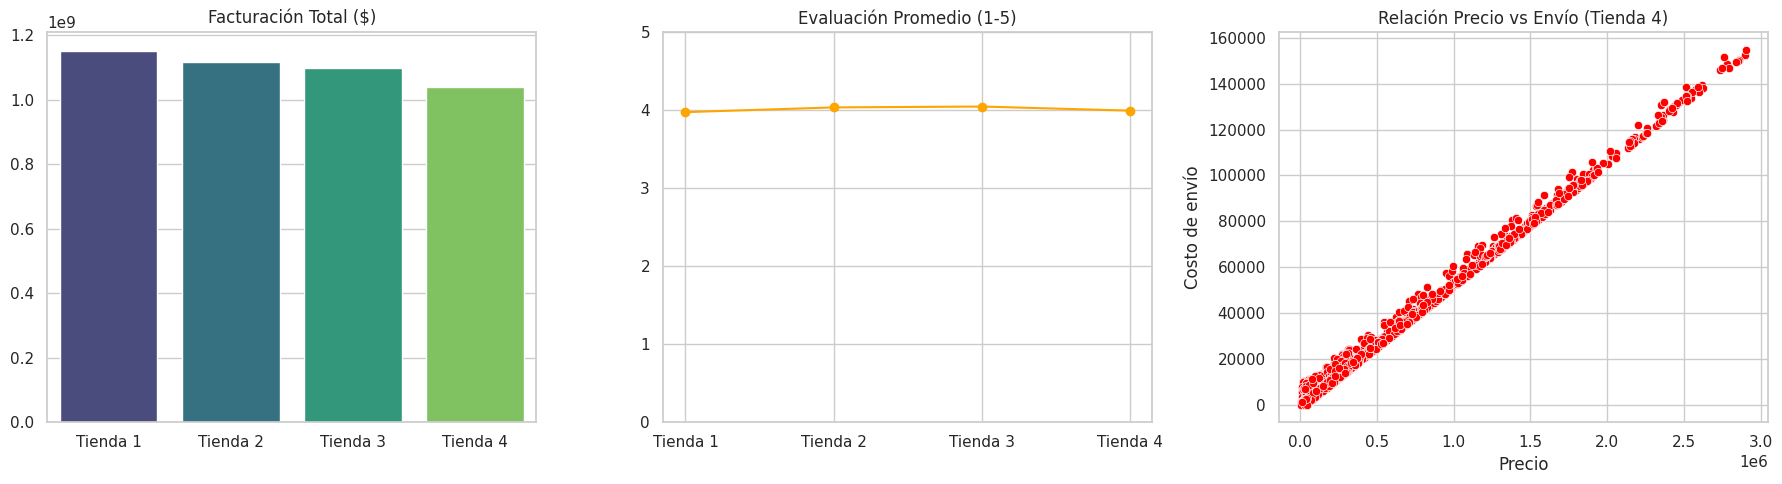

In [10]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Gráfico de Barras: Facturación
sns.barplot(x=nombres, y=facturacion, ax=axes[0], palette="viridis")
axes[0].set_title('Facturación Total ($)')

# 2. Gráfico de Líneas: Calificaciones
axes[1].plot(nombres, promedio_eval, marker='o', linestyle='-', color='orange')
axes[1].set_title('Evaluación Promedio (1-5)')
axes[1].set_ylim(0, 5)

# 3. Gráfico de Dispersión: Precio vs Envío (Tienda 4)
sns.scatterplot(data=tienda4, x='Precio', y='Costo de envío', ax=axes[2], color='red')
axes[2].set_title('Relación Precio vs Envío (Tienda 4)')

plt.tight_layout()
plt.show()

# Análisis Geográfico - Extra (Código)

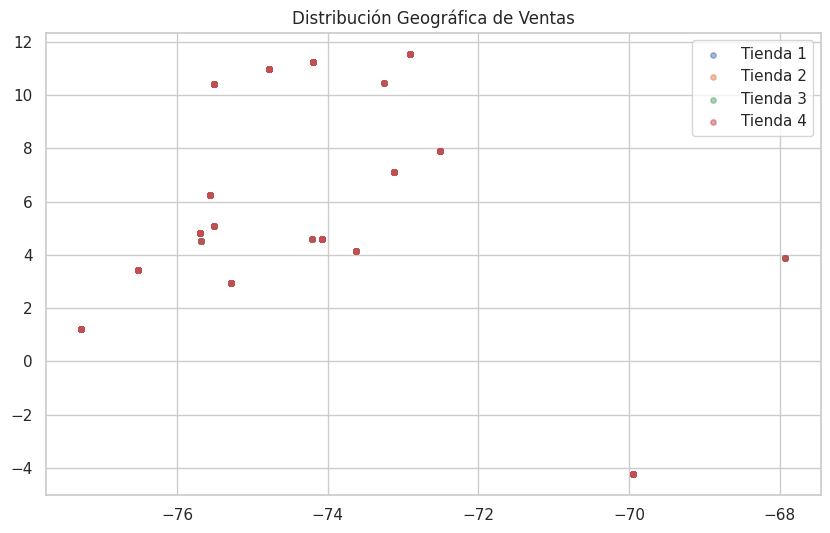

In [11]:
plt.figure(figsize=(10, 6))
for i, df in enumerate(tiendas):
    plt.scatter(df['lon'], df['lat'], label=nombres[i], alpha=0.5, s=15)

plt.title('Distribución Geográfica de Ventas')
plt.legend()
plt.show()

## 📝 Informe Final para el Sr. Juan

**Análisis General:**
Tras evaluar las cuatro tiendas, se observa que la **Tienda 4** es la que presenta el menor desempeño financiero, con una facturación total de aproximadamente **$1,038,376,400**.

**Justificación de la Recomendación:**
1. **Facturación:** La Tienda 4 genera los ingresos más bajos del grupo.
2. **Evaluaciones:** Aunque la Tienda 1 tiene calificaciones ligeramente más bajas, su volumen de ventas es mucho mayor, lo que indica un negocio más sólido que solo requiere mejoras operativas.
3. **Logística:** La Tienda 4 tiene el costo de envío más bajo, pero esto no se traduce en una mayor cantidad de ventas o captación de clientes.

**Decisión:**
Se recomienda vender la **Tienda 4**. Esta acción permitirá al Sr. Juan obtener liquidez de la unidad menos rentable para invertir en su nuevo proyecto, manteniendo las tres tiendas con mayor volumen de ingresos.